# Criação de Rede Neural Convolucional para o CIFAR10

In [1]:
# importando as bibliotecas
import torch
import matplotlib.pyplot as plt
import torchvision
from torchvision import transforms
import numpy as np
import random
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
from PIL import Image

In [2]:
# selecionando o device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
# importando o CIFAR10
transform = transforms.Compose([transforms.ToTensor()])

train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True,transform=transform)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True,transform=transform)

100%|██████████| 170M/170M [00:04<00:00, 34.9MB/s]


In [4]:
# dataset de treino
train_set.data.shape

(50000, 32, 32, 3)

In [5]:
# dataset de teste
test_set.data.shape

(10000, 32, 32, 3)

**Calculando a média e o desvio padrão do dataset**

In [6]:
imgs = torch.stack([_ for _, i in train_set],dim=3)
imgs.shape

torch.Size([3, 32, 32, 50000])

In [7]:
imgs.view(3,-1).mean(dim=1) #media

tensor([0.4914, 0.4822, 0.4465])

In [8]:
imgs.view(3,-1).std(dim=1) # desvio padrão

tensor([0.2470, 0.2435, 0.2616])

**Estes valores serão passados na normalização do dataset**

In [9]:
# importando o CIFAR10 com a normalização

transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize(mean= [0.4914, 0.4822, 0.4465],
                                std = [0.2470, 0.2435, 0.2616])])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True,transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True,transform=transform)

In [10]:
# definição das classes
classes = {
    0:'plane',
    1:'car',
    2:'bird',
    3:'cat',
    4:'deer',
    5:'dog',
    6:'frog',
    7:'horse',
    8:'ship',
    9:'truck'
}

In [11]:
# Acessando o primeiro item (imagem e rótulo)
imagem, rotulo = train_set[0]

print("Shape da imagem:", imagem.shape)  # (3, 32, 32)
print("Rótulo:", rotulo)

Shape da imagem: torch.Size([3, 32, 32])
Rótulo: 6


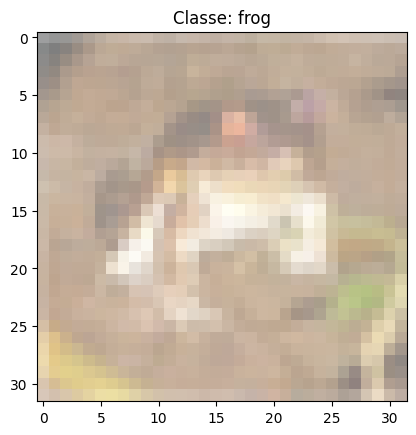

In [12]:
# Desfaz a normalização para exibir corretamente
img = imagem * 0.5 + 0.5  # desfaz Normalization
npimg = img.numpy()
plt.imshow(np.transpose(npimg, (1, 2, 0))) # de (C, H, W) → vira (H, W, C)
plt.title(f"Classe: {classes[rotulo]}")
plt.show()

## Data Augmentation

O processo de Data Augmentation realiza transformações nas imagens originais com o intuito de criar variações durante o treinamento. Essa técnica pode ser utilizada como uma estratégia especialmente útil para conjuntos de dados pequenos, criando maior variabilidade nas entradas e, consequentemente, aumentando a capacidade de generalização do modelo.

In [13]:
def show_images(images, titles=None, cols=5):
    rows = (len(images) + cols - 1) // cols
    plt.figure(figsize=(cols * 3, rows * 3))

    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)

        # Se for tensor PyTorch, converte para NumPy e reorganiza os eixos
        if torch.is_tensor(img):
            img = img.clone()  # para evitar alterações no original
            if img.ndim == 3 and img.shape[0] in [1, 3]:  # (C, H, W)
                img = img * 0.5 + 0.5  # desfaz Normalize, se necessário
                img = img.numpy()
                img = np.transpose(img, (1, 2, 0))  # (H, W, C)
            else:
                img = img.numpy()

        plt.imshow(img)
        if titles is not None:
            plt.title(titles[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()


In [14]:
example_images = [train_set[i][0] for i in random.sample(range(len(train_set)), 5)]

Imagem Original


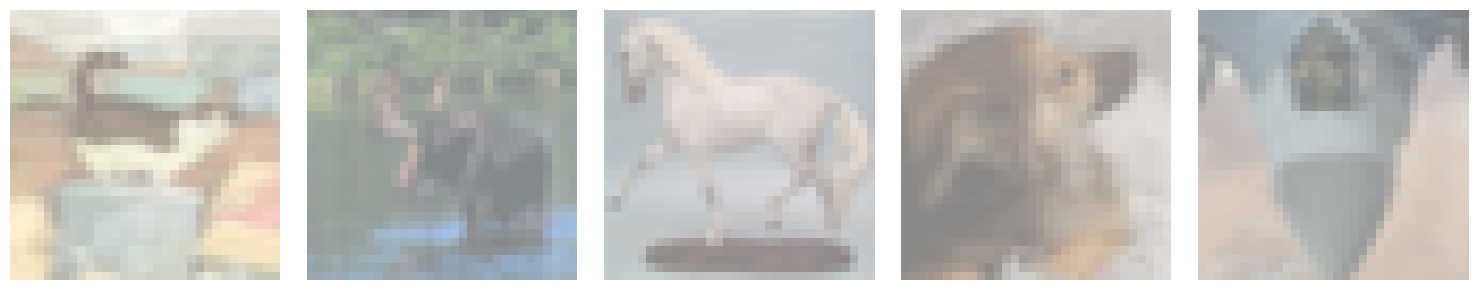

Após RandomResizedCrop


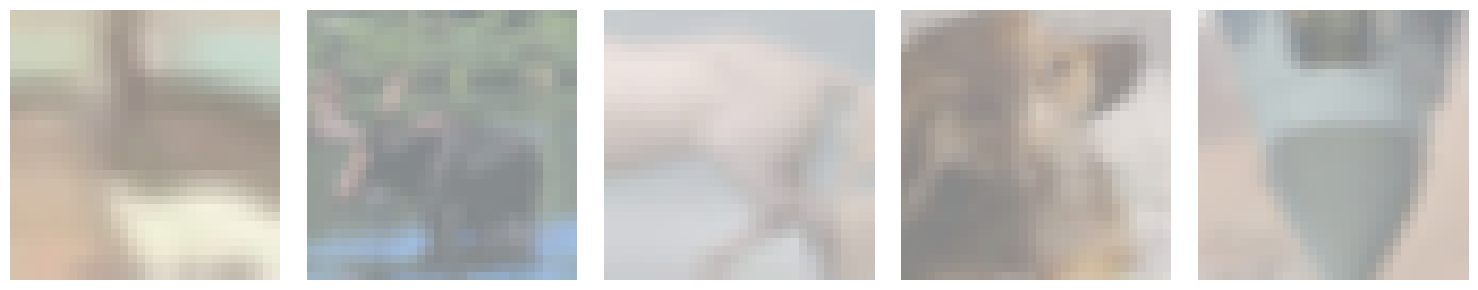

Após RandomHorizontalFlip


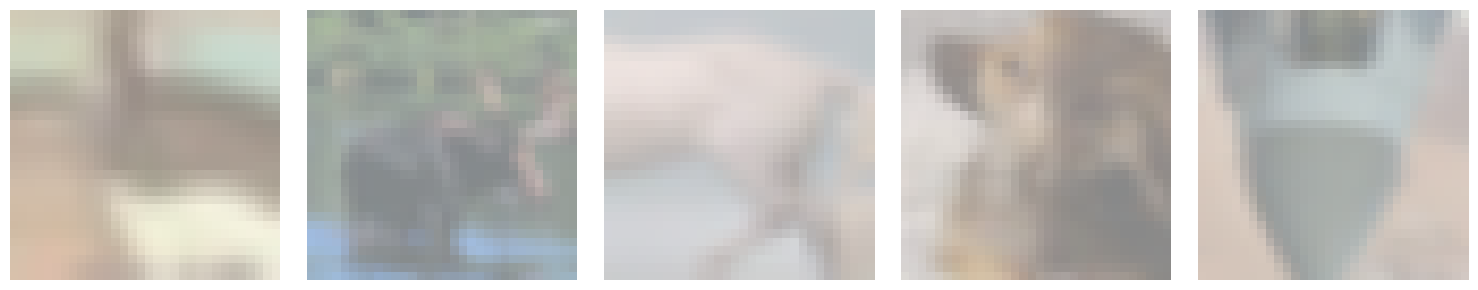

Após RandomRotation


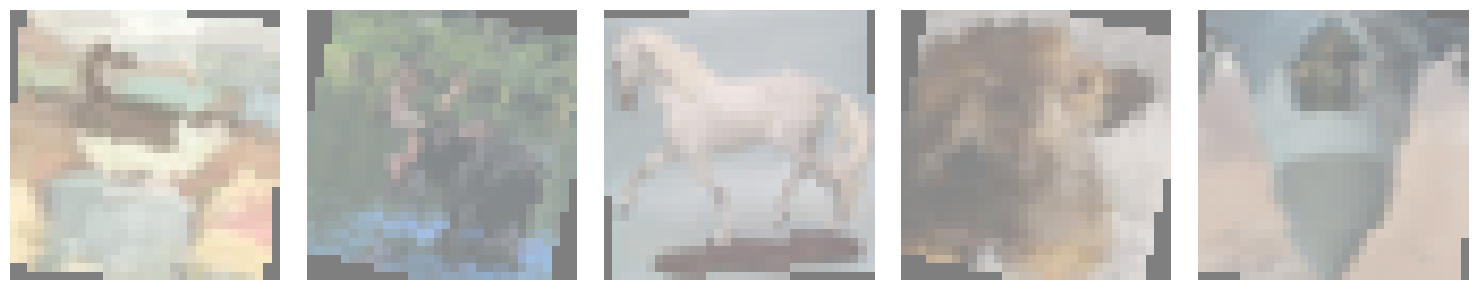

Após RandomAffine


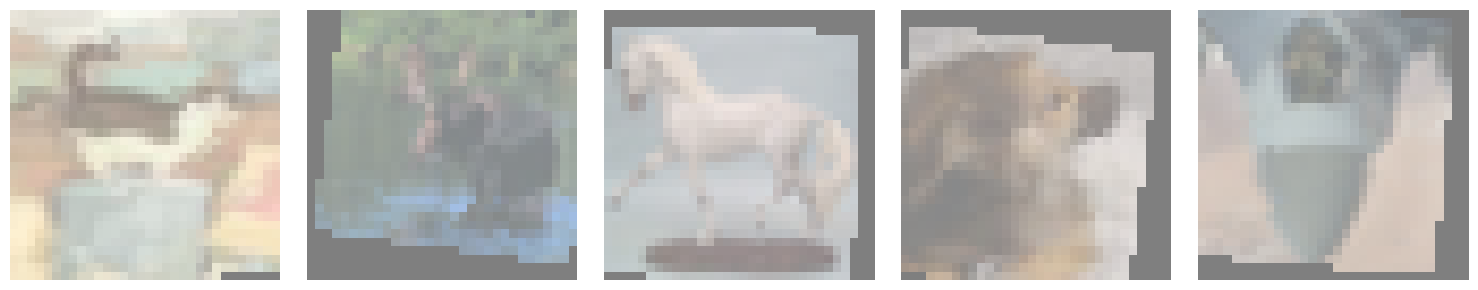

In [58]:
# Imagem original
print("Imagem Original")
show_images(example_images)

# Exemplo de RandomResizedCrop
cropped_images = [transforms.RandomResizedCrop(32)(img) for img in example_images]
print("Após RandomResizedCrop")
show_images(cropped_images)

# Exemplo de RandomHorizontalFlip
flipped_images = [transforms.RandomHorizontalFlip()(img) for img in cropped_images]
print("Após RandomHorizontalFlip")
show_images(flipped_images)

# Exemplo de RandomRotation
rotated_images = [transforms.RandomRotation(15)(img) for img in example_images]
print("Após RandomRotation")
show_images(rotated_images)

# Exemplo de RandomAffine
affined_images = [transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1))(img) for img in example_images]
print("Após RandomAffine")
show_images(affined_images)

## Aplicando o modelo com Data Augmentation

In [16]:
# Incluindo as transformações do data augmentation
transform_aug = transforms.Compose([
    transforms.RandomResizedCrop(32),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean= [0.4914, 0.4822, 0.4465],std = [0.2470, 0.2435, 0.2616])])

In [17]:
trainset_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=False,transform=transform_aug) #50.000
testset_aug = torchvision.datasets.CIFAR10(root='./data', train=False, download=False,transform=transform_aug) #10.000

# criando o conjunto de validação a partir do trainset
# vamos separar 90% dos dados do conjunto do trainset para treinamento e 10% dele para validação

size_trainset = int(len(trainset) * 0.9)
size_valset = len(trainset) - size_trainset

print(f"Tamanho do conjunto de treinamento: {float(size_trainset):.0f}\nTamanho do conjunto de validação: {float(size_valset):.0f}")

# separando aleatoriamente os dados
trainset_aug, val_set_aug = random_split(trainset, [size_trainset, size_valset])

Tamanho do conjunto de treinamento: 45000
Tamanho do conjunto de validação: 5000


**Criação do DataLoader**

In [18]:
trainset_loader_aug = DataLoader(trainset_aug, batch_size=32, shuffle=True)
valset_loader_aug = DataLoader(val_set_aug, batch_size=32, shuffle=True)
testset_loader_aug = DataLoader(testset_aug, batch_size=32, shuffle=True)

**Criação da CNN**

In [19]:
class CNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 8, kernel_size=3)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3)

        self.fc1 = nn.Linear(16 * 6 * 6, 32)
        self.fc2 = nn.Linear(32, num_classes)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), kernel_size=2)
        x = F.max_pool2d(F.relu(self.conv2(x)), kernel_size=2)
        x = x.view(-1, 16 * 6 * 6)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [20]:
def train_model(model, trainloader, valloader, criterion, optimizer, device, num_epochs=5):
    history = {
        'train_losses': [],
        'val_losses': [],
        'train_accuracies': [],
        'val_accuracies': []
    }

    for epoch in range(num_epochs):
        # Treinamento
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for i, data in tqdm(enumerate(trainloader, 0), total=len(trainloader)):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(trainloader)
        train_acc = 100 * correct / total
        history['train_losses'].append(train_loss)
        history['train_accuracies'].append(train_acc)
        print(f'Epoch {epoch+1}, Train Loss: {train_loss:.3f}, Train Accuracy: {train_acc:.2f}%')

        # Validação
        model.eval()
        val_running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for data in valloader:
                inputs, labels = data
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(valloader)
        val_acc = 100 * correct / total
        history['val_losses'].append(val_loss)
        history['val_accuracies'].append(val_acc)
        print(f'Epoch {epoch+1}, Val Loss: {val_loss:.3f}, Val Accuracy: {val_acc:.2f}%')

    print('Treinamento concluído')
    return history


def test_model(model, testloader):
    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f'Acurácia da rede na base de teste: {100 * correct / total:.2f}%')


def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history['train_losses'], label='Train')
    ax1.plot(history['val_losses'], label='Validation')
    ax1.set_title('Loss')
    ax1.legend()

    ax2.plot(history['train_accuracies'], label='Train')
    ax2.plot(history['val_accuracies'], label='Validation')
    ax2.set_title('Accuracy')
    ax2.legend()

    plt.show()

100%|██████████| 1407/1407 [00:13<00:00, 107.18it/s]


Epoch 1, Train Loss: 1.578, Train Accuracy: 42.76%
Epoch 1, Val Loss: 1.401, Val Accuracy: 50.50%


100%|██████████| 1407/1407 [00:13<00:00, 106.89it/s]


Epoch 2, Train Loss: 1.279, Train Accuracy: 54.51%
Epoch 2, Val Loss: 1.243, Val Accuracy: 55.40%


100%|██████████| 1407/1407 [00:13<00:00, 106.91it/s]


...

Epoch 28, Train Loss: 0.896, Train Accuracy: 68.54%
Epoch 28, Val Loss: 1.208, Val Accuracy: 60.48%


100%|██████████| 1407/1407 [00:13<00:00, 106.34it/s]


Epoch 29, Train Loss: 0.890, Train Accuracy: 68.77%
Epoch 29, Val Loss: 1.236, Val Accuracy: 60.16%


100%|██████████| 1407/1407 [00:13<00:00, 107.14it/s]


Epoch 30, Train Loss: 0.886, Train Accuracy: 69.04%
Epoch 30, Val Loss: 1.320, Val Accuracy: 58.56%
Treinamento concluído


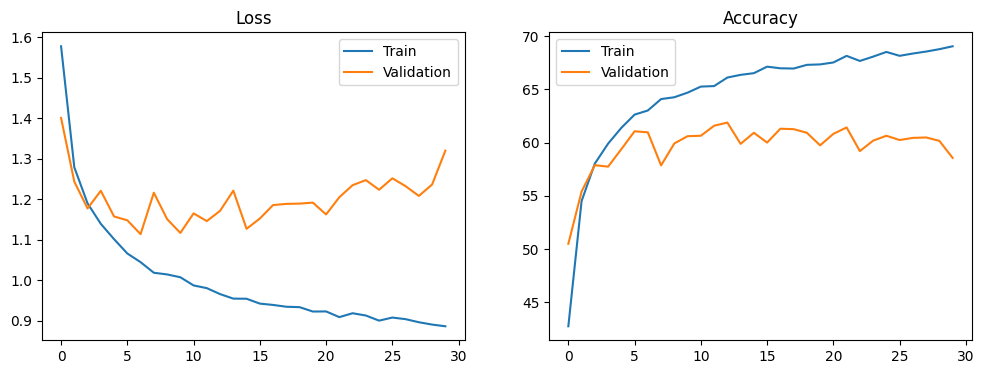

In [27]:
# treinamento do modelo
model_aug = CNN(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_aug.parameters(), lr=0.01, momentum=0.9)

history = train_model(model_aug, trainset_loader_aug, valset_loader_aug, criterion, optimizer,device, num_epochs=30)

plot_history(history)

## Aplicando o modelo sem Data Augmentation

In [28]:
# Incluindo as transformações do data augmentation
transform_no_aug = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean= [0.4914, 0.4822, 0.4465],std = [0.2470, 0.2435, 0.2616])])

In [29]:
trainset_no_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=False,transform=transform_no_aug) #50.000
testset_no_aug = torchvision.datasets.CIFAR10(root='./data', train=False, download=False,transform=transform_no_aug) #10.000

# criando o conjunto de validação a partir do trainset
# vamos separar 90% dos dados do conjunto do trainset para treinamento e 10% dele para validação

size_trainset = int(len(trainset_no_aug) * 0.9)
size_valset = len(trainset_no_aug) - size_trainset

print(f"Tamanho do conjunto de treinamento: {float(size_trainset):.0f}\nTamanho do conjunto de validação: {float(size_valset):.0f}")

# separando aleatoriamente os dados
trainset_no_aug, val_set_no_aug = random_split(trainset_no_aug, [size_trainset, size_valset])

Tamanho do conjunto de treinamento: 45000
Tamanho do conjunto de validação: 5000


**Criação do DataLoader**

In [30]:
trainset_loader_no_aug = DataLoader(trainset_no_aug, batch_size=32, shuffle=True)
valset_loader_no_aug = DataLoader(val_set_no_aug, batch_size=32, shuffle=True)
testset_loader_no_aug = DataLoader(testset_no_aug, batch_size=32, shuffle=True)

**Treinando o modelo**

100%|██████████| 1407/1407 [00:13<00:00, 106.48it/s]


Epoch 1, Train Loss: 1.581, Train Accuracy: 42.46%
Epoch 1, Val Loss: 1.306, Val Accuracy: 53.54%


100%|██████████| 1407/1407 [00:13<00:00, 107.90it/s]


Epoch 2, Train Loss: 1.281, Train Accuracy: 54.64%
Epoch 2, Val Loss: 1.265, Val Accuracy: 54.58%


100%|██████████| 1407/1407 [00:13<00:00, 107.56it/s]


...

Epoch 28, Train Loss: 0.883, Train Accuracy: 69.11%
Epoch 28, Val Loss: 1.250, Val Accuracy: 60.16%


100%|██████████| 1407/1407 [00:13<00:00, 103.77it/s]


Epoch 29, Train Loss: 0.883, Train Accuracy: 69.03%
Epoch 29, Val Loss: 1.224, Val Accuracy: 60.06%


100%|██████████| 1407/1407 [00:13<00:00, 106.86it/s]


Epoch 30, Train Loss: 0.879, Train Accuracy: 69.26%
Epoch 30, Val Loss: 1.281, Val Accuracy: 59.22%
Treinamento concluído


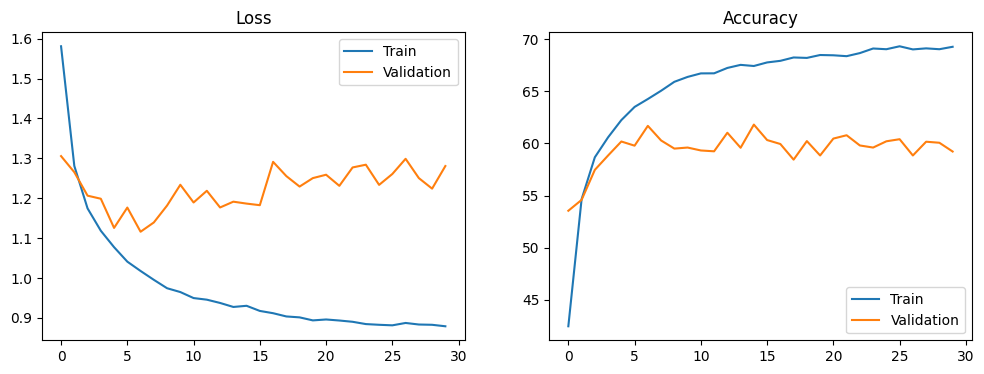

In [31]:
# treinamento do modelo
model_no_aug = CNN(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_no_aug.parameters(), lr=0.01, momentum=0.9)

history = train_model(model_no_aug, trainset_loader_no_aug, valset_loader_no_aug, criterion, optimizer,device, num_epochs=30)

plot_history(history)

## Testando os modelos com novas imagens

In [47]:
# passaro
img = Image.open('passaro.jpg')

In [48]:
img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((32,32)),
    transforms.Normalize(mean= [0.4914, 0.4822, 0.4465],std = [0.2470, 0.2435, 0.2616])])

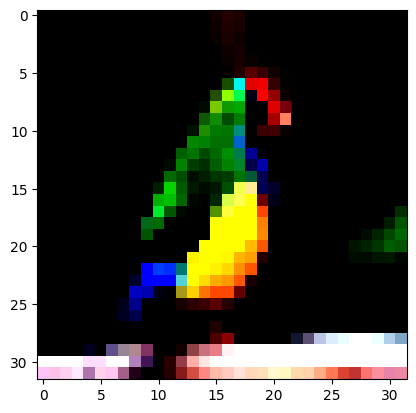

In [49]:
img_tensor = img_transform(img)
plt.imshow(img_tensor.permute(1, 2, 0))

In [50]:
batch = img_tensor.unsqueeze(0).to(device)

modelo com data augmentation

In [36]:
model_aug.eval()

CNN(
  (conv1): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=576, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=10, bias=True)
)

In [51]:
output_aug = model_aug(batch)
output_aug

tensor([[-0.2405, -2.5607,  1.6004, -0.3350, -0.7272, -0.8041, -0.2768, -0.6079,
         -0.1350, -0.4168]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [52]:
probs = torch.nn.functional.softmax(output_aug, dim=1) * 100
prob_result = {}
for i, n in enumerate(classes):
  prob = probs[0][i].item()
  prob_result[n] = [prob]

In [53]:
# relembrando as categorias
classes

{0: 'plane',
 1: 'car',
 2: 'bird',
 3: 'cat',
 4: 'deer',
 5: 'dog',
 6: 'frog',
 7: 'horse',
 8: 'ship',
 9: 'truck'}

In [54]:
prob_result

{0: [7.6334991455078125],
 1: [0.7499730587005615],
 2: [48.106563568115234],
 3: [6.944723606109619],
 4: [4.691671371459961],
 5: [4.344428539276123],
 6: [7.361079692840576],
 7: [5.286218643188477],
 8: [8.482760429382324],
 9: [6.399083137512207]}

modelo sem data augmentation

In [43]:
model_no_aug.eval()

CNN(
  (conv1): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=576, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=10, bias=True)
)

In [55]:
output_no_aug = model_no_aug(batch)
output_no_aug

tensor([[ 0.0683,  0.4284, 13.0160, -0.6421,  0.9080, -0.7603,  1.7281, -1.2158,
         -4.1454, -8.4198]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [56]:
probs = torch.nn.functional.softmax(output_no_aug, dim=1) * 100
prob_result = {}
for i, n in enumerate(classes):
  prob = probs[0][i].item()
  prob_result[n] = [prob]

In [57]:
prob_result

{0: [0.0002381652593612671],
 1: [0.00034140501520596445],
 2: [99.997314453125],
 3: [0.00011704155622282997],
 4: [0.0005515057127922773],
 5: [0.00010399213351774961],
 6: [0.0012522888137027621],
 7: [6.59459110465832e-05],
 8: [3.522678753142827e-06],
 9: [4.903714767579004e-08]}